In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal

In [2]:
class QuadState(TypedDict):
    
    a:int
    b:int
    c:int
    
    equation: str
    discriminant: float
    result: str

In [3]:
def show_eqation(state: QuadState):
    equation = f'{state["a"]}x2 {state["b"]}x {state["c"]}'
    
    return {"equation" : equation}


def calculate_discriminant(state: QuadState):
    
    discriminant = state["b"]**2 - (4*state["a"]*state["c"])
    
    return {"discriminant": discriminant} 

def real_roots(state: QuadState):
    
    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"]) 
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"]) 
    
    result = f'two roots are {root1} and {root2}'
    
    return {"result": result}


def repeated_roots(state: QuadState):
    
    root = (-state["b"])/(2*state["a"]) 
    
    result = f'two repeated roots are {root}'
    
    return {"result": result}


def img_roots(state: QuadState):
    result = f'No real roots'
    
    return {"result": result}

def check_conditions(state: QuadState) -> Literal["real_roots" , "repeated_roots" , "img_roots"]:
    
    if state["discriminant"] > 0:
        return "real_roots"
    elif state["discriminant"] == 0:
        return "repeated_roots"
    else:
        return "img_roots"

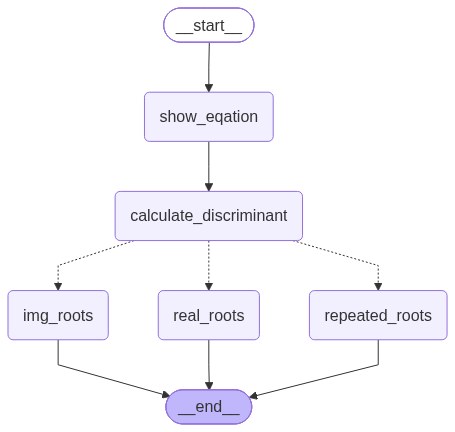

In [4]:
graph = StateGraph(QuadState)
graph.add_node("show_eqation" , show_eqation)
graph.add_node("calculate_discriminant" , calculate_discriminant)
graph.add_node("real_roots" , real_roots)
graph.add_node("repeated_roots" , repeated_roots)
graph.add_node("img_roots" , img_roots)

graph.add_edge(START , "show_eqation")
graph.add_edge("show_eqation" , "calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant" , check_conditions)
graph.add_edge("real_roots" , END)
graph.add_edge("repeated_roots" , END)
graph.add_edge("img_roots" , END)

workflow = graph.compile()
workflow

In [ ]:
initial = {
    "a": 4,
    "b": 6,
    "c": 8
}

workflow.invoke(initial)

{'a': 4,
 'b': 6,
 'c': 8,
 'equation': '4x2 6x 8',
 'discriminant': -92,
 'result': 'No real roots'}